In [3]:
import pandas as pd
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize
import spacy
nlp = spacy.load('en_core_web_sm')
from scipy import stats


from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

os.getcwd()

'/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/code'

In [4]:
firstdf = pd.concat([
    pd.read_csv('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/mediacloud2016.csv'),
    pd.read_csv('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/mediacloud2017.csv'),
    pd.read_csv('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/mediacloud2018.csv'),
    pd.read_csv('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/mediacloud2019.csv')
], ignore_index=True)

In [5]:
# My dataset is huge, and I only want to include rows with certain words included. 
#To do this, I am using keywords to match 
keywords = [
    r'\brape\b',
    r'\braped\b',
    r'\braping\b',
    r'\brapist\b',
    r'\bassault\b',
    r'\babuse\b',
    r'\bharassment\b',
    r'\bmisconduct\b',
    r'\bmetoo\b',
    r'#metoo\b',
    r'\bme too\b',
    r'\bsexual.violence',
    r'\bgroping\b',
    r'\bnonconsensual\b',
]

#join together the keywords
pattern = '|'.join(keywords)

# Search in title 
mask = firstdf['title'].str.contains(pattern, flags=re.IGNORECASE, na=False)

# also check the URL for the keywords
mask |= firstdf['url'].str.contains(pattern, flags=re.IGNORECASE, na=False)

filtered = firstdf[mask].copy()

#Seeing how many rows carry over
print(f"{len(filtered)} matching rows out of {len(firstdf)} total")
filtered.to_csv('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/filtered_metoo_assault.csv', index=False)

115525 matching rows out of 470225 total


In [6]:
filtered["title"].head(10)

15    Bill Clinton’s ‘Rape’ Victim Story Debunked—Ju...
17    Donald Trump's campaign manager accuses lawmak...
39    Amber Tamblyn shares assault story after Trump...
46    Donald Trump continues to insist that sexual a...
70    Pence turns rape apologist on CNN — but goes d...
77    Amber Tamblyn's story of her sexual assault is...
81    Trump attacked one of his attempted rape accus...
83    Trump campaign planned for Bill Clinton's accu...
87    Man accused of raping teenage relative can't b...
93    Man accused of raping teenage relative can't b...
Name: title, dtype: object

In [7]:
df = pd.read_csv('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/filtered_metoo_assault.csv')
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['title_clean'] = df['title'].fillna('').str.strip()

In [8]:
df.shape

(115525, 9)

perpetrator_focus         0.205886
metoo_movement            0.199238
institutional_response    0.112850
survivor_focus            0.043575
dtype: float64


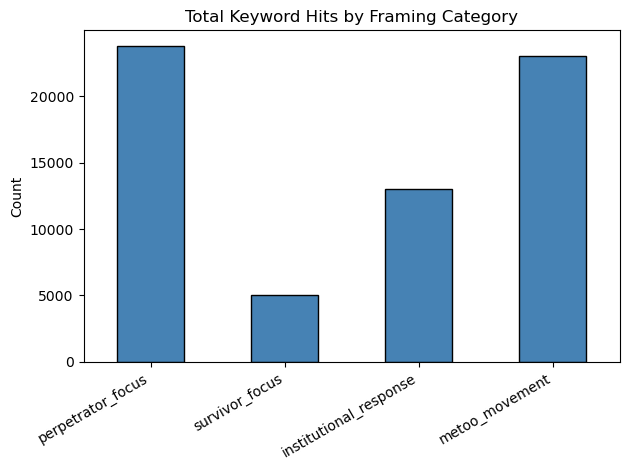

In [9]:
# Define thematic dictionaries
dictionaries = {
    'perpetrator_focus': [
        'accused', 'alleged', 'charged', 'convicted', 'arrested',
        'suspect', 'predator', 'abuser', 'offender'
    ],
    'survivor_focus': [
        'survivor', 'spoke out', 'came forward', 'alleged victim',
        'accuser', 'complainant', 'testimony',
    ],
    'institutional_response': [
        'fired', 'resigned', 'suspended', 'investigation', 'lawsuit',
        'settlement', 'trial', 'verdict', 'sentence', 'acquitted'
    ],
    'metoo_movement': [
        'metoo', 'me too', '#metoo', 'movement', 'reckoning'
    ]
}

def score_title(title, word_list):
    title_lower = title.lower()
    return sum(1 for term in word_list if term in title_lower)

for category, words in dictionaries.items():
    df[category] = df['title_clean'].apply(lambda t: score_title(t, words))

# Summary: mean score per category
print(df[list(dictionaries.keys())].mean().sort_values(ascending=False))

# Bar chart of total hits per category
df[list(dictionaries.keys())].sum().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Keyword Hits by Framing Category')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

=== Before Oct 17, 2017 ===
perpetrator_focus         0.233090
institutional_response    0.160924
survivor_focus            0.041351
metoo_movement            0.011568
dtype: float64

=== After Oct 17, 2017 ===
metoo_movement            0.365816
perpetrator_focus         0.169306
institutional_response    0.085574
survivor_focus            0.038955
dtype: float64


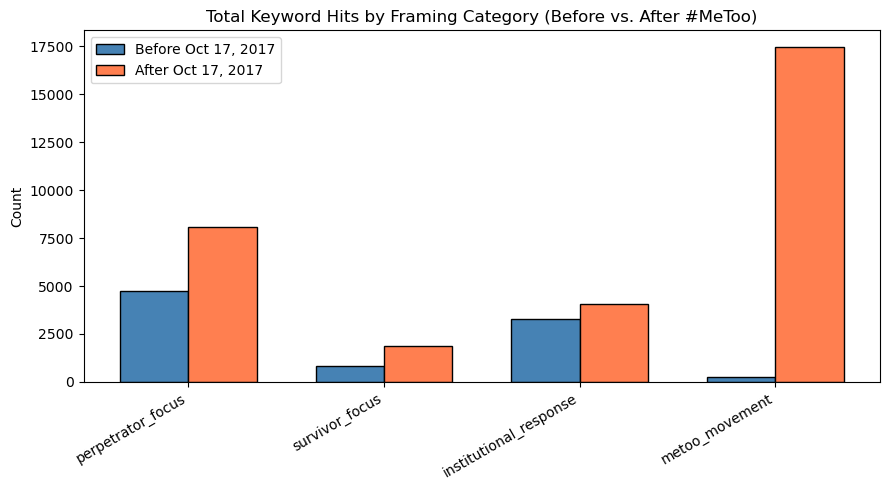

In [30]:
# Define split date
split_date   = pd.Timestamp('2017-10-17')
ayearbefore  = pd.Timestamp('2016-10-17')
ayearafter   = pd.Timestamp('2018-10-17')

df_before = df[(df['publish_date'] >= ayearbefore) & (df['publish_date'] < split_date)].copy()
df_after  = df[(df['publish_date'] >= split_date)  & (df['publish_date'] < ayearafter)].copy()
# Define thematic dictionaries
dictionaries = {
    'perpetrator_focus': [
        'accused', 'alleged', 'charged', 'convicted', 'arrested',
        'suspect', 'predator', 'abuser', 'offender'
    ],
    'survivor_focus': [
        'survivor', 'spoke out', 'came forward', 'alleged victim',
        'accuser', 'complainant', 'testimony',
    ],
    'institutional_response': [
        'fired', 'resigned', 'suspended', 'investigation', 'lawsuit',
        'settlement', 'trial', 'verdict', 'sentence', 'acquitted'
    ],
    'metoo_movement': [
        'metoo', 'me too', '#metoo', 'movement', 'reckoning'
    ]
}

def score_title(title, word_list):
    title_lower = title.lower()
    return sum(1 for term in word_list if term in title_lower)

# Score both subsets
categories = list(dictionaries.keys())
for category, words in dictionaries.items():
    for subset in [df_before, df_after]:
        subset[category] = subset['title_clean'].apply(lambda t: score_title(t, words))

# --- Summary: mean score per category ---
print("=== Before Oct 17, 2017 ===")
print(df_before[categories].mean().sort_values(ascending=False))
print("\n=== After Oct 17, 2017 ===")
print(df_after[categories].mean().sort_values(ascending=False))

# --- Side-by-side bar chart ---

before_totals = df_before[categories].sum()
after_totals  = df_after[categories].sum()

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, before_totals, width, label='Before Oct 17, 2017',
       color='steelblue', edgecolor='black')
ax.bar(x + width/2, after_totals,  width, label='After Oct 17, 2017',
       color='coral', edgecolor='black')

ax.set_title('Total Keyword Hits by Framing Category (Before vs. After #MeToo)')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

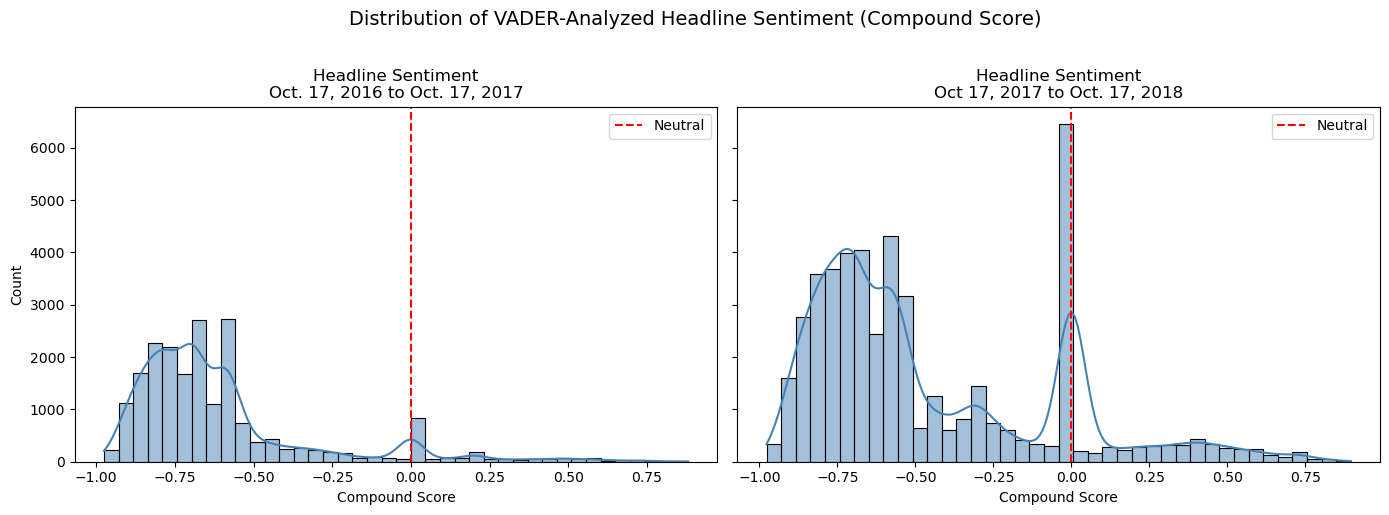

In [32]:
sia = SentimentIntensityAnalyzer()

# Extend lexicon with domain-relevant terms
domain_lexicon = {
    'survivor': 1.0,    # slightly positive framing
    'brave': 2.0,
    'courageous': 2.0,
    'alleged': -1.0,    # c asts doubt
    'acquitted': 0.3,
    'strong': 1.0,
    'believe': 0.5,
    'reckoning': 1.0,
    'rallying': 1.5,
    'silence breaker': 2.0,
    'silence breakers': 2.0,
    'powerful': 2.0,
    'wins': 1.0,
    'victory': 1.5,
    'empower': 2
}
sia.lexicon.update(domain_lexicon)

df['sentiment'] = df['title_clean'].apply(sia.polarity_scores)
df['compound']  = df['sentiment'].apply(lambda x: x['compound'])
df['positive']  = df['sentiment'].apply(lambda x: x['pos'])
df['negative']  = df['sentiment'].apply(lambda x: x['neg'])
df['neutral']   = df['sentiment'].apply(lambda x: x['neu'])

# Distribution of compound scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, subset, label in zip(axes,
                              [df_before, df_after],
                              ['Oct. 17, 2016 to Oct. 17, 2017', 'Oct 17, 2017 to Oct. 17, 2018']):
    sns.histplot(subset['compound'], bins=40, kde=True, color='steelblue', ax=ax)
    ax.axvline(0, color='red', linestyle='--', label='Neutral')
    ax.set_title(f'Headline Sentiment\n{label}')
    ax.set_xlabel('Compound Score')
    ax.legend()

plt.suptitle('Distribution of VADER-Analyzed Headline Sentiment (Compound Score)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/output/sentiment_distribution.png', bbox_inches='tight')
plt.show()


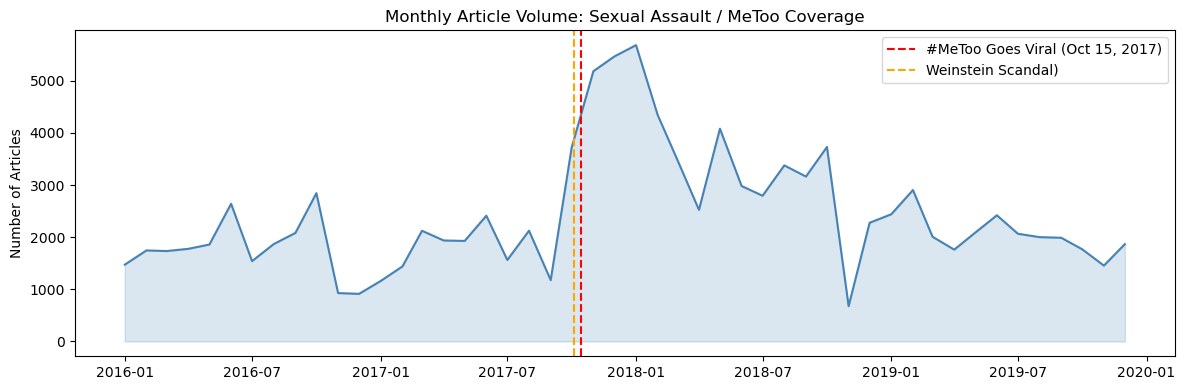

In [12]:
df_dated = df.dropna(subset=['publish_date']).copy()
df_dated['year_month'] = df_dated['publish_date'].dt.to_period('M')

# Article volume over time
volume = df_dated.groupby('year_month').size()
volume.index = volume.index.to_timestamp()

plt.figure(figsize=(12, 4))
plt.plot(volume.index, volume.values, color='steelblue')
plt.fill_between(volume.index, volume.values, alpha=0.2, color='steelblue')
plt.title('Monthly Article Volume: Sexual Assault / MeToo Coverage')
plt.axvline(x=pd.Timestamp('2017-10-15'), color='red', linestyle='--', 
            linewidth=1.5, label='#MeToo Goes Viral (Oct 15, 2017)')
plt.axvline(x=pd.Timestamp('2017-10-05'), color='orange', linestyle='--', 
            linewidth=1.5, label='Weinstein Scandal)')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.legend()
plt.show()


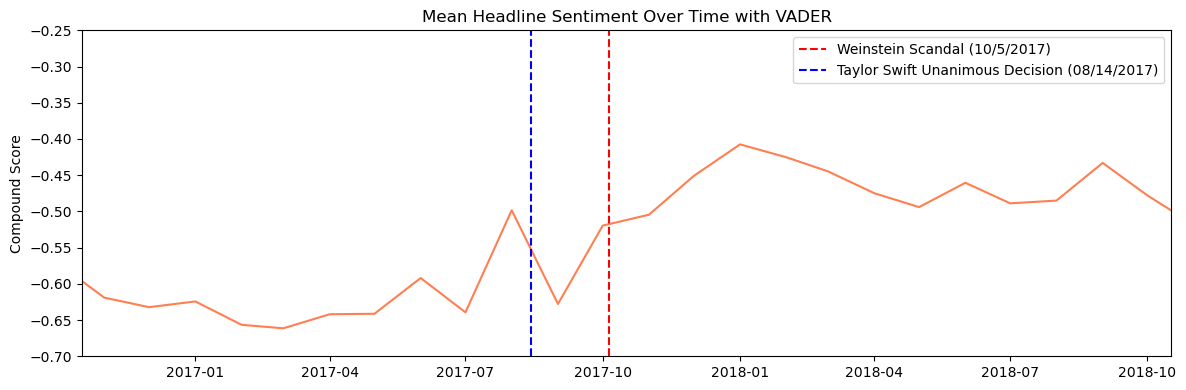

In [35]:
sent_time = df_dated.groupby('year_month')['compound'].mean()
sent_time.index = sent_time.index.to_timestamp()

plt.figure(figsize=(12, 4))
plt.plot(sent_time.index, sent_time.values, color='coral')
plt.axhline(0, color='gray', linestyle='--')

# Just pass the date directly since x-axis is datetime
plt.axvline(x=pd.Timestamp('2017-10-05'), color='red', linestyle='--', 
            linewidth=1.5, label='Weinstein Scandal (10/5/2017)')
plt.axvline(x=pd.Timestamp('2017-08-14'), color='blue', linestyle='--', 
            linewidth=1.5, label='Taylor Swift Unanimous Decision (08/14/2017)')
plt.title('Mean Headline Sentiment Over Time with VADER')
plt.ylabel('Compound Score')
plt.legend()
plt.xlim(pd.Timestamp('2016-10-17'), pd.Timestamp('2018-10-17'))
plt.ylim(-0.7, -0.25)
plt.tight_layout()
plt.savefig('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/output/meanheadlinesentimentvader.png', bbox_inches='tight')
plt.show()

In [14]:
##########

In [15]:
df['publish_date'] = pd.to_datetime(df['publish_date'])
metoodate = pd.Timestamp('2017-10-17')
oneyearbeforemetoodate = pd.Timestamp('2016-10-17')
oneyearaftermetoodate = pd.Timestamp('2018-10-17')

before = df[(df['publish_date'] < metoodate) & (df['publish_date'] > oneyearbeforemetoodate)]['compound']
after  = df[(df['publish_date'] >= metoodate) & (df['publish_date'] < oneyearaftermetoodate)]['compound']

In [16]:
df['compound']

0        -0.5267
1        -0.7096
2        -0.3818
3        -0.3182
4        -0.8898
           ...  
115520   -0.6908
115521   -0.7717
115522   -0.6249
115523   -0.8625
115524   -0.7964
Name: compound, Length: 115525, dtype: float64

In [17]:
stat, p = stats.mannwhitneyu(before, after, alternative='less')
print(f"U statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

U statistic: 369382210.5000
P-value: 0.0000


In [18]:
print(f"Median sentiment before: {before.median():.4f}")
print(f"Median sentiment after:  {after.median():.4f}")
print(f"Mean sentiment before: {before.mean():.4f}")
print(f"Mean sentiment after:  {after.mean():.4f}")
print(f"N before: {len(before)}")
print(f"N after:  {len(after)}")

# Effect size ( -1 to 1)
n1, n2 = len(before), len(after)
r = 1 - (2 * stat) / (n1 * n2)
print(f"Effect size (r): {r:.4f}")

Median sentiment before: -0.6908
Median sentiment after:  -0.5859
Mean sentiment before: -0.6109
Mean sentiment after:  -0.4604
N before: 20249
N after:  47748
Effect size (r): 0.2359
